# RAG experimentation  
This notebook contains set of RAG experiments

## Data Import Block  
This block imports pdf data and generates chunks

In [65]:

from PyPDF2 import PdfReader
from pydantic import BaseModel
from typing import Optional, List
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

docs_path = "../data/documents/"
documents_titles = os.listdir(docs_path)


class DocumentObject(BaseModel):
    document: str
    pages: list

class PageObject(BaseModel):
    page_number: int
    text: str
    size: int
    document: str


document_title = documents_titles[0]
def process_document(document_title):
    
    """Processes document and returns a DocumentObject with all its pages processed.

    Args:
        document_title (str): document file name

    Returns:
        DocumentObject: Document object
    """
    
    document_path = os.path.join(docs_path, documents_titles[0])
    reader = PdfReader(document_path)
    
    page_objects = []
    
    # process each page to generate PageObject
    for i, page in enumerate(reader.pages):
        
        page_text = page.extract_text()
        page_size = int(len(page_text)/4.7)
        page_object = PageObject(page_number=i+1, text=page_text, size=page_size, document=document_title)
        
        page_objects.append(page_object.model_dump())
    
    # creates DocumentObject with PageObjects' contents
    document_object = DocumentObject(document=document_title, pages=page_objects)
    
    return document_object





class Chunk(BaseModel):
    text: str
    pages: List[int]
    token_count: int
    document: str

def create_chunks(document_object, chunk_size):
    """
    Creates fixed-size text chunks from a DocumentObject. If a page has fewer tokens than chunk_size,
    tokens from subsequent pages are taken to fill the chunk. In cases where a single page contributes
    tokens to a chunk, the 'pages' field will contain a list of one page number; if tokens come from
    multiple pages, that list will include all relevant page numbers.
    
    Args:
        document_object (DocumentObject): The processed document containing pages.
        chunk_size (int): Desired number of tokens per chunk.
        
    Returns:
        list: A list of dictionaries, each with keys:
            - "chunk_text": A string containing exactly chunk_size tokens.
            - "pages": A list of page numbers that contributed tokens for this chunk.
    """
    # Build a combined list of (token, page_number) tuples
    tokens_with_page = []
    for page in document_object.pages:
        # Split text into tokens (using default whitespace splitting)
        tokens = page["text"].split()
        # Add each token with its source page number
        tokens_with_page.extend([(token, page["page_number"]) for token in tokens])
    
    chunks = []
    total_tokens = len(tokens_with_page)
    
    # Iterate over tokens_with_page in steps of chunk_size
    # This ensures each chunk is exactly chunk_size tokens
    for i in range(0, total_tokens - chunk_size + 1, chunk_size):
        chunk_slice = tokens_with_page[i:i+chunk_size]
        # Reconstruct the chunk text from tokens
        chunk_text = " ".join(token for token, _ in chunk_slice)
        # Collect the page numbers (maintaining order and uniqueness)
        pages = []
        for _, page_number in chunk_slice:
            if page_number not in pages:
                pages.append(page_number)
                
                
        chunk = Chunk(
            text=chunk_text,
            pages=pages,
            token_count=len(chunk_slice),
            document=document_object.document
        )
        chunks.append(chunk.model_dump())
        
    return chunks



        

In [66]:
chunk_size = 200

document_title = "Concepts in Thermal Physics - S. Blundell, K. Blundell (Oxford, 2006) WW.pdf"

document_object = process_document(document_title)
chunks = create_chunks(document_object, chunk_size)

In [67]:
chunks[0]

{'text': 'CONCEPTS IN THERMAL PHYSICS This page intentionally left blank Concepts in Thermal Physics STEPHEN J. BLUNDELL AND KA THERINE M. BLUNDELL Department of Physics, University of Oxford, UK 1 3 Great Clarendon Street, Oxford OX26DP Oxford University Press is a department of the University of Oxford. It furthers the University’s objective of excellence in research, scholarship, and education by publishing worldwide in Oxford New York Auckland Cape Town Dar es Salaam Hong Kong Karachi Kuala Lumpur Madrid Melbourne Mexico City Nairobi New Delhi Shanghai Taipei Toronto With offices in Argentina Austria Brazil Chile Czech Republic France Greece Guatemala Hungary Italy Japan Poland Portugal Singapore South Korea Switzerland Thailand Turkey Ukraine Vietnam Oxford is a registered trade mark of Oxford University Press in the UK and in certain other countries Published in the United States by Oxford University Press Inc., New York © Oxford University Press 2006 The moral rights of the auth

## Retrieval Block  
This block experiments with different Retrieval techniques.  
Covers Vectorization and Similarity search

In [68]:
import numpy as np
from sentence_transformers import SentenceTransformer

In [81]:
#model_1 = SentenceTransformer('paraphrase-MiniLM-L6-v2')
#model_2 = SentenceTransformer("Snowflake/snowflake-arctic-embed-l")
embeddings_model_id = "intfloat/e5-large-v2"
embeddings_model = SentenceTransformer(embeddings_model_id)

In [70]:
def create_embeddings(chunks,embeddings_model):
    
    for chunk in chunks:
        embedding = embeddings_model.encode(chunk["text"])
        chunk["embedding"] = embedding
        
    return chunks

In [71]:
embeddings = create_embeddings(chunks,embeddings_model_id)

In [82]:
# UNLOADING THE MODEL AND FREE GPU MEMORY



del embeddings_model_id
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

### DB mgnt

In [73]:
embeddings[0]['embedding'].tolist()

[0.013319471850991249,
 -0.045676056295633316,
 0.057370416820049286,
 -0.022644376382231712,
 -0.01859414204955101,
 0.03154093399643898,
 -0.05356795713305473,
 -0.005407955497503281,
 -0.046034689992666245,
 0.010758994147181511,
 0.019059903919696808,
 -0.05568632110953331,
 0.013580108061432838,
 0.02349640429019928,
 0.006978943478316069,
 0.015394747257232666,
 -0.011984829790890217,
 0.012287967838346958,
 0.014003343880176544,
 -0.03624274209141731,
 0.005941031966358423,
 -0.0265129953622818,
 -0.0343400277197361,
 0.048878394067287445,
 -0.015316804870963097,
 -0.06156338006258011,
 -0.02053697407245636,
 -0.008099962957203388,
 -0.017481666058301926,
 -0.0032979012466967106,
 0.017022838816046715,
 0.04455617442727089,
 0.02541162818670273,
 -0.0430137999355793,
 0.029487095773220062,
 0.01925072632730007,
 -0.03989493101835251,
 -0.03991061821579933,
 -0.008830789476633072,
 -0.022047769278287888,
 -0.0025080370251089334,
 0.05063632130622864,
 -0.04790327697992325,
 0.049

In [74]:
import psycopg2 as psql
from psycopg2 import sql

from dotenv import load_dotenv

load_dotenv()


True

In [87]:
db_user = "llmp"
db_password = 'Akechi21234'
db_host = "127.0.0.1"
db_port = "5432"
db_database = "rag_db"


DB_CONFIG = {
    "dbname": db_database,
    "user": db_user,
    "password": db_password,
    "host": db_host
}


def ensure_table_exists():
    """Creates the document_chunks table if it doesn't exist."""
    create_table_query = """
    CREATE TABLE IF NOT EXISTS embeddings_table_v2 (
        id SERIAL PRIMARY KEY,
        document TEXT NOT NULL,
        text TEXT NOT NULL,
        pages INTEGER[],
        token_count INTEGER,
        embedding JSONB,
        embeddings_model TEXT,
        UNIQUE (text, document, embeddings_model)
    );
    """
    conn = psql.connect(**DB_CONFIG)
    cur = conn.cursor()
    cur.execute(create_table_query)
    conn.commit()
    cur.close()
    conn.close()
    
    
# VECTOR EXTENSION FOR POSTRGRES IS NOT WORKING, WILL PROCEED WITH OTHER APPROACH FOR SAVING EMBEDDINGS

In [88]:
ensure_table_exists()

In [100]:
import json

def save_embeddings(embeddings):
    """Saves a list of chunks with embeddings into PostgreSQL."""
    ensure_table_exists()  # Ensure table exists before inserting

    conn = psql.connect(**DB_CONFIG)
    cur = conn.cursor()

    insert_query = """
    INSERT INTO embeddings_table_v2 (text, pages, token_count, document, embedding, embeddings_model)
    VALUES (%s, %s, %s, %s, %s, %s)
    ON CONFLICT (text, document, embeddings_model) DO NOTHING;  -- Skips duplicates
    """

    for embedding in embeddings:
        # Convert NumPy array to Python list for JSON storage
        embedding_vector = embedding["embedding"].tolist()
        try:
            cur.execute(insert_query, (
                    embedding["text"],
                    embedding["pages"],
                    embedding["token_count"],
                    embedding["document"],
                    json.dumps(embedding_vector),
                    embeddings_model# Convert list to JSONB
                ))
        except:
            continue

    conn.commit()
    cur.close()
    conn.close()

In [101]:
save_embeddings(embeddings)

### Retrieval

In [102]:
def retrieve_embeddings():
    
    
    conn = psql.connect(**DB_CONFIG)
    cur = conn.cursor()
    
    # Fetch all embeddings from the database
    cur.execute("SELECT id, text, pages, token_count, embedding, embeddings_model, document FROM embeddings_table_v2;")
    results = cur.fetchall()
    cur.close()
    conn.close()
    
    return results

In [103]:
db_embeddings = retrieve_embeddings()

In [108]:
db_embeddings[0]

(1,
 'CONCEPTS IN THERMAL PHYSICS This page intentionally left blank Concepts in Thermal Physics STEPHEN J. BLUNDELL AND KA THERINE M. BLUNDELL Department of Physics, University of Oxford, UK 1 3 Great Clarendon Street, Oxford OX26DP Oxford University Press is a department of the University of Oxford. It furthers the University’s objective of excellence in research, scholarship, and education by publishing worldwide in Oxford New York Auckland Cape Town Dar es Salaam Hong Kong Karachi Kuala Lumpur Madrid Melbourne Mexico City Nairobi New Delhi Shanghai Taipei Toronto With offices in Argentina Austria Brazil Chile Czech Republic France Greece Guatemala Hungary Italy Japan Poland Portugal Singapore South Korea Switzerland Thailand Turkey Ukraine Vietnam Oxford is a registered trade mark of Oxford University Press in the UK and in certain other countries Published in the United States by Oxford University Press Inc., New York © Oxford University Press 2006 The moral rights of the authors 

In [109]:
class EmbeddingChunk(BaseModel):
    id:int
    text:str
    pages:List[int]
    token_count:int
    embedding:List[float]
    document:str
    similarity:float

def convert_chunk_to_json(embedding_tuple):
    
    return EmbeddingChunk(
        id=embedding_tuple[0][0],
        text=embedding_tuple[0][1],
        pages=embedding_tuple[0][2],
        token_count=embedding_tuple[0][3],
        embedding=embedding_tuple[0][4],
        embeddings_model=embedding_tuple[0][5],
        document=embedding_tuple[0][6],
        similarity=embedding_tuple[1]
    ).model_dump()
    
    
def semantic_search(user_input,db_embeddings, top_k):
    
    model = SentenceTransformer("intfloat/e5-large-v2")
    
    
    user_embedding = model.encode(user_input)
    
    # Calculate cosine similarity between user input and all embeddings
    similarities = []
    for db_embedding in db_embeddings:
        db_embedding_vector = np.array(db_embedding[4])
        similarity = np.dot(user_embedding, db_embedding_vector) / (np.linalg.norm(user_embedding) * np.linalg.norm(db_embedding_vector))
        similarities.append((db_embedding, similarity))
        
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        
    # Sort by similarity
    similarities.sort(key=lambda x: x[1], reverse=True)
    similarities = [convert_chunk_to_json(similarity) for similarity in similarities]
    #similarities = process_similarities(similarities)
    
    # Return top_p results
    return similarities[:top_k]

In [110]:
user_input = 'What is enthalpy?'
top_k = 5
selected_chunks = semantic_search(user_input,db_embeddings, top_k)

In [112]:
len(selected_chunks)

5

##### USE NORMALIZED EMBEDDINGS MODEL WITH DOT PRODUCT

## Context processing

In [113]:
from sentence_transformers import CrossEncoder


cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

#results = cross_encoder.predict([question, chunks[0]['text']])
#results = cross_encoder.predict([[llmp_response, tool] for tool in self.tools_desc.keys()])

In [121]:


def softmax(x):
    """Computes softmax for an array of scores."""
    exp_x = np.exp(x - np.max(x))  # Subtract max score for numerical stability
    return exp_x / exp_x.sum()

results = cross_encoder.predict([[user_input, chunk['text']] for chunk in selected_chunks])/200
softmax_scores = softmax(results)

threshold = 0.01

filtered_chunks = [selected_chunks[i] for i, score in enumerate(softmax_scores) if score > threshold]

context = " ".join([chunk['text'] for chunk in filtered_chunks])

In [122]:
context

'the system at con- stant pressure, the enthalpy Hof the system goes up. If heat is provided bythe system to its surroundings Hgoes down.ditions are relatively easy to obtain: an experiment which is open to the air in a laboratory is usually at constant pressure since pressure is provided by the atmosphere.4We also conclude from eqn 16.9 that if 4At a given latitude, the atmosphere provides a constant pressure, small changes due to weather fronts notwith- standing.bothSandpare constant, we have that d H=0 . Equation 16.9 also implies that T=/parenleftbigg∂H ∂S/parenrightbigg p, (16.13) 166Thermodynamic potentials and V=/parenleftbigg∂H ∂p/parenrightbigg S. (16.14) Both UandHsuﬀer from the drawback that one of their natural v a r i a b l e si st h ee n t r o p y S, which is not a very easy parameter to vary in a lab. It would be more convenient if we could substitute that for the temperature T, which is, of course, a much easier quantity to control and to vary. This is accomplished for 

In [123]:
import requests
from typing import List, Dict, Optional
from dotenv import load_dotenv
import numpy as np

load_dotenv()

class GenerateRequest(BaseModel):
    model: str
    system_prompt: str = ''
    prompt: str
    format: Optional[dict] = None
    image: Optional[str] = None
    tools: Optional[List[Dict]] = None
    src: str = None
    
    
llmp_url = os.getenv("LLMP_URL")
llmp_password = os.getenv("LLMP_PASSWORD")

def llmp_call(prompt, system_prompt, model):
        """ 
        Call the LLMP API to generate a response
        All related to the call is processed here
        """
        
        headers = {
        "Content-Type": "application/json",
        "Authorization": llmp_password
    }
        
        # Construct request payload
        request_data = GenerateRequest(
        model=model,
        system_prompt=system_prompt,
        prompt=prompt,
        tools=None,
        src="RAG test")
        
        payload = request_data.model_dump(exclude_none=True)

        try:
            response = requests.post(llmp_url, headers=headers, json=payload)
            response.raise_for_status()  # Raise an error for bad responses (4xx, 5xx)
            return response.json()
        except requests.exceptions.RequestException as e:
            print(f"Request failed: {e}")
            return None
        
def process_context(user_input,selected_chunks):
    """
    Processes context to be fed into the LLM.
    """
    results = cross_encoder.predict([[user_input, chunk['text']] for chunk in selected_chunks])/200
    softmax_scores = softmax(results)

    threshold = 0.01

    filtered_chunks = [selected_chunks[i] for i, score in enumerate(softmax_scores) if score > threshold]

    context = " ".join([chunk['text'] for chunk in filtered_chunks])
    
    return context


system_prompt = "You are an assistant. Your provide answers based on provided text."





model = "llama3.2:latest"
    
    
def softmax(x):
    """Computes softmax for an array of scores."""
    exp_x = np.exp(x - np.max(x))  # Subtract max score for numerical stability
    return exp_x / exp_x.sum()
            


In [136]:

documents = {chunk['document'] for chunk in selected_chunks}
unique_pages = []
seen = set()

for chunk in selected_chunks:
    for page in chunk["pages"]:
        if page not in seen:
            unique_pages.append(page)
            seen.add(page)
            


user_prompt = "What is enthalpy?"
context = process_context(user_prompt,selected_chunks)
prompt = f"Based only on the following in markdown: {context} \nAnswer this: {user_prompt}"

response = llmp_call(prompt, system_prompt, model)

print(F"""{response['message']['content']}\n
      documents: {documents}\n
      pages: {unique_pages}""")

Enthalpy (H) is defined as:

H = U + PV

where:
- U is the internal energy of the system
- P is the pressure of the system
- V is the volume of the system

This definition together with equation 16.1 imply that dH =TdS - pdV + pdV + Vdp =TdS + Vdp.

The natural variables for H are thus S and p, and we have that H = H(S,p).

Therefore, enthalpy is a thermodynamic potential that represents the total energy of a system including the internal energy (U), the pressure-volume work, and the heat transferred.

      documents: {'Concepts in Thermal Physics - S. Blundell, K. Blundell (Oxford, 2006) WW.pdf'}

      pages: [184, 185, 188, 189, 182, 183, 13, 14]


In [130]:
selected_chunks

[{'id': 309,
  'text': 'the system at con- stant pressure, the enthalpy Hof the system goes up. If heat is provided bythe system to its surroundings Hgoes down.ditions are relatively easy to obtain: an experiment which is open to the air in a laboratory is usually at constant pressure since pressure is provided by the atmosphere.4We also conclude from eqn 16.9 that if 4At a given latitude, the atmosphere provides a constant pressure, small changes due to weather fronts notwith- standing.bothSandpare constant, we have that d H=0 . Equation 16.9 also implies that T=/parenleftbigg∂H ∂S/parenrightbigg p, (16.13) 166Thermodynamic potentials and V=/parenleftbigg∂H ∂p/parenrightbigg S. (16.14) Both UandHsuﬀer from the drawback that one of their natural v a r i a b l e si st h ee n t r o p y S, which is not a very easy parameter to vary in a lab. It would be more convenient if we could substitute that for the temperature T, which is, of course, a much easier quantity to control and to vary. Th

In [39]:
response = generate_rag(user_prompt)

In [44]:
print(chunks[306]['text'])

of the functions of state p,V,TandSin such a way as to give the resulting quantity the dimensions of energy. These new functions of state are called thermodynamic potentials , and examples include U+TS, U−pV,U+2pV−3TS. However, most thermodynamic potentials that one could pick are really not very useful (including the ones we’ve just used as examples!) but three of them are extremely useful and are given special symbols: H=U+pV,F=U−TSandG=U+pV−TS. In this chapter, we will explore why these three quantities are so useful. First, however, we will review some properties concerning the internalenergy U. 16.1 Internal energy, U Let us review the results concerning the internal energy that were derived in Section 14.3. Changes in the internal energy Uof a system are given by the ﬁrst law of thermodynamics written in the form (eqn 14.17): dU=TdS−pdV. (16.1) This equation shows that the natural variables1to describe UareSand1See Section 14.3. V, since changes in Uare due to changes in Sand/or 

In [46]:
chunks[307]

{'text': '16.1 implies that the temperature Tcan be expressed as a diﬀerential of Uusing T=/parenleftbigg∂U ∂S/parenrightbigg V, (16.3) and similarly the pressure pcan be expressed as p=−/parenleftbigg∂U ∂V/parenrightbigg S. (16.4) 16.2 Enthalpy, H165 We also have that for isochoric processes (where isochoric means that Vis constant), dU=TdS, (16.5) and for reversible2isochoric processes2For a reversible process, ¯ dQ=TdS, see Section 14.3. dU=¯dQrev=CVdT, (16.6) and hence ∆U=/integraldisplayT2 T1CVdT. (16.7) This is only true for systems held at constant volume; we would like to be able to extend this to systems held at constant pressure (an easier constraint to apply experimentally), and this can be achieved using the thermodynamic potential called enthalpy which we describe next. 16.2 Enthalpy, H We deﬁne the enthalpy Hby H=U+PV. (16.8) This deﬁnition together with eqn 16.1 imply that dH=TdS−pdV+pdV+Vdp =TdS+Vdp. (16.9) The natural variables for Hare thus Sandp, and we have that H= 

In [23]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

In [55]:
response['message']['content']
response_score = cross_encoder.predict([user_prompt, response['message']['content']])

In [56]:
print(response['message']['content'])

Enthalpy (H) is a thermodynamic property that represents the total energy of a system, including both internal energy (U) and the energy associated with the pressure and volume of a system. It is defined as:

H = U + pV

where p is the pressure and V is the volume of the system.

In other words, enthalpy is a measure of the heat content of a system, taking into account both the internal energy of the system itself and the work done by the system against its surroundings. Enthalpy is an extensive property, meaning it depends on the size of the system.

Enthalpy plays an important role in thermodynamics, particularly in processes such as combustion, chemical reactions, and phase changes. It is used to describe the energy changes that occur during these processes, allowing us to predict and understand the behavior of complex systems.


In [57]:
response_score

9.73465

In [48]:
import numpy as np



results = cross_encoder.predict([[user_prompt, chunk['text']] for chunk in chunks])/200

def softmax(x):
    """Computes softmax for an array of scores."""
    exp_x = np.exp(x - np.max(x))  # Subtract max score for numerical stability
    return exp_x / exp_x.sum()

# Apply softmax to all scores
softmax_scores = softmax(results)

# Set a threshold (e.g., 0.2, meaning only chunks with softmax score > 0.2 are kept)
threshold = 0.0013

# Filter chunks based on threshold
filtered_chunks = [chunks[i] for i, score in enumerate(softmax_scores) if score > threshold]

# Print or return the filtered chunks
print(filtered_chunks)


[{'text': 'For atoms to be tossed perpetually In endless motion through the mighty void.” (On the Nature of Things, Lucretius, 1st century BC) “...(we) have borne the burden of the workand the heatof the day.” (Matthew 20:12, 1st century AD) Thermal physics forms a key part of any undergraduate physics course. It includes the fundamentals of classical thermodynamics (which was founded largely in the nineteenth century and motivated by a desire to understand the conversion of heat into work using engines) and also sta- tistical mechanics (which was founded by Boltzmann and Gibbs, and is concerned with the statistical behaviour of the underlying microstates of the system). Students often ﬁnd these topics hard, and this problem is not helped by a lack of familiarity with basic concepts in mathematics, particularly in probability and statistics. Moreover, the traditional focus of thermodynamics on steam engines seems remote and largely irrelevantto a twenty-ﬁrst century student. This is un

In [46]:
softmax_scores.hist()

array([0.0012963 , 0.00129254, 0.00130163, 0.00129615, 0.00129925,
       0.00129814, 0.00130226, 0.00129336, 0.00130093, 0.00129559,
       0.00129506, 0.00129531, 0.00129726, 0.00129911, 0.00129487,
       0.00129691, 0.00130049, 0.00129449, 0.00130013, 0.00129395,
       0.0012947 , 0.00129298, 0.00129346, 0.00130062, 0.0013022 ,
       0.0013004 , 0.00129717, 0.00129819, 0.00130177, 0.0013004 ,
       0.00130064, 0.00130162, 0.00129728, 0.00129366, 0.00129694,
       0.00130001, 0.00134278, 0.00130118, 0.00129467, 0.00129788,
       0.00129327, 0.00129666, 0.00130047, 0.00129603, 0.00129643,
       0.00129486, 0.00129903, 0.00129466, 0.00129482, 0.00129498,
       0.00129801, 0.00129512, 0.00129622, 0.00129512, 0.00129883,
       0.00129719, 0.00129774, 0.00130291, 0.00129806, 0.00129632,
       0.00129637, 0.00129875, 0.00129421, 0.0012925 , 0.00130162,
       0.00129655, 0.00130222, 0.00129717, 0.00129611, 0.00130375,
       0.00129991, 0.00130216, 0.00129938, 0.00129824, 0.00129

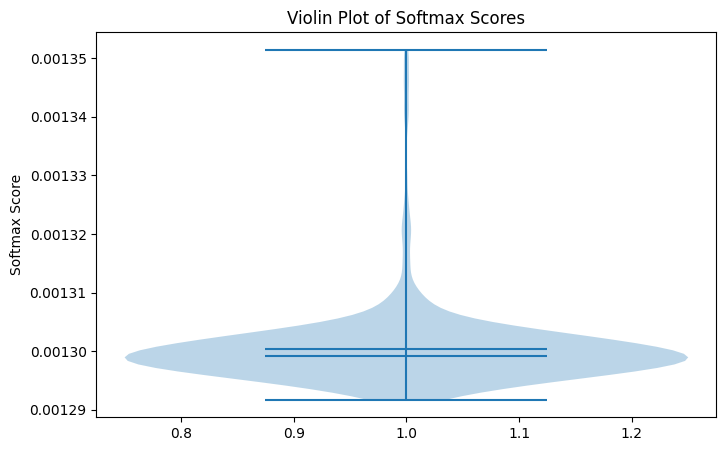

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.violinplot(softmax_scores, showmeans=True, showmedians=True)
plt.title("Violin Plot of Softmax Scores")
plt.ylabel("Softmax Score")
plt.show()